In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA

In [45]:
# Import provided data from multi-sheet xlsx files
folderpath = (
    Path("..")
    / "data"
    / "The Water Sector Meets Mathematics_ V-KEMS Virtual Study Group-20260323T171309Z-3-001"
    / "Challenge 1"
)
filepath = folderpath / "VKEMS challenge 1 data.xlsx"
with open(filepath, "r") as file:
    df = pd.read_excel(filepath, sheet_name=None)

# Show imported Excel sheet names
print(df.keys())

dict_keys(['Zones', 'ESW', 'NW'])


In [46]:
for name in ["ESW", "NW"]:
    df[name] = df[name].set_index("m3/day")
    # Drop negative values
    # df[name].clip(lower=0, inplace=True)
    # Drop row named "Company"
    # df[name] = df[name].drop("Company")
df["ESW"].head()

,2001-12-30 00:00:00,2002-01-06 00:00:00,2002-01-13 00:00:00,2002-01-20 00:00:00,2002-01-27 00:00:00,2002-02-03 00:00:00,2002-02-10 00:00:00,2002-02-17 00:00:00,2002-02-24 00:00:00,2002-03-03 00:00:00,...,2025-12-21 00:00:00,2025-12-28 00:00:00,2026-01-04 00:00:00,2026-01-11 00:00:00,2026-01-18 00:00:00,2026-01-25 00:00:00,2026-02-01 00:00:00,2026-02-08 00:00:00,2026-02-15 00:00:00,2026-02-22 00:00:00
m3/day,,,,,,,,,,,,,,,,,,,,,
Zone BA,2254.67,2449.26,1844.97,1804.43,1634.04,1272.75,1234.16,1162.12,888.43,835.05,...,648.69,1097.20,1980.00,1258.34,590.01,667.89,1097.22,1162.83,1038.94,925.50
Zone AA,6825.71,7377.76,6842.04,6143.70,5903.38,5727.11,6745.02,7030.34,7014.64,7202.31,...,4295.36,5336.64,6225.23,6098.52,5967.35,5554.46,4962.48,4840.18,4119.60,3748.10
Zone AB,1980.04,1848.01,1777.42,1604.10,1584.04,1617.91,1804.83,1981.57,1704.07,1908.06,...,997.22,1179.91,1805.91,1378.86,1494.35,1165.28,1219.06,1303.36,1319.73,1178.11
Zone AF,1071.39,778.27,751.58,755.68,885.01,840.65,758.42,812.58,774.71,700.47,...,1204.77,1464.65,2174.19,1988.73,1543.42,1436.00,1273.40,1310.95,1630.51,1543.92
Zone AG,12094.82,12664.09,11996.94,10757.68,10110.27,10291.58,10359.24,10580.23,10148.91,9364.99,...,7090.58,7851.16,9859.68,8959.75,8301.45,7745.43,7135.03,7017.75,6587.50,5823.00


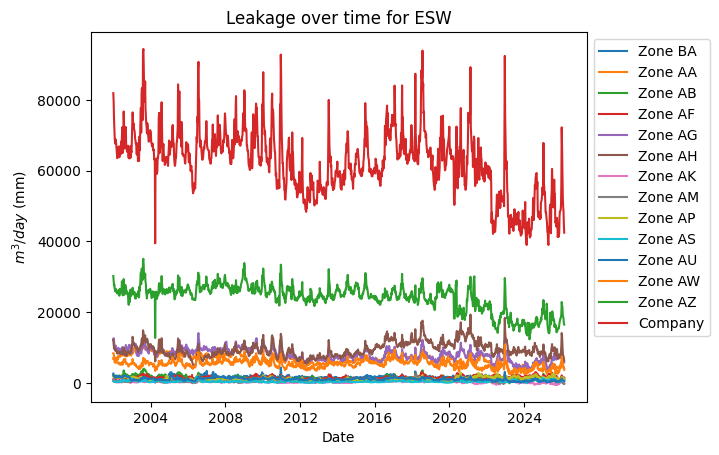

In [47]:
for index, row in df["ESW"].iterrows():
    plt.plot(row.index, row.values)

plt.xlabel("Date")
plt.ylabel("$m^3/day$ (mm)")
plt.title("Leakage over time for ESW")
plt.legend(df["ESW"].index, loc="upper left", bbox_to_anchor=(1, 1))
# For later usage, assign the plot to a variable and show it


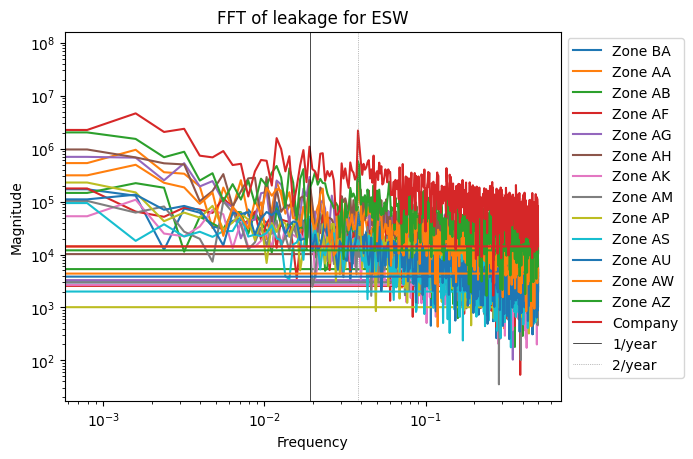

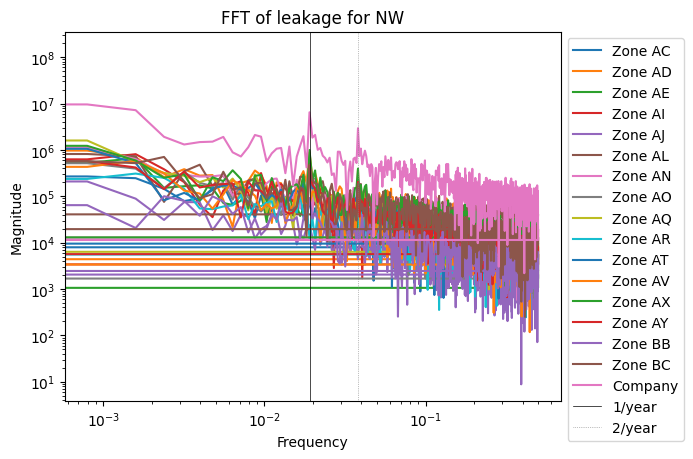

In [48]:
# Plot each zones Fourier transform
for name in ["ESW", "NW"]:
    for index, row in df[name].iterrows():
        fft = np.abs(np.fft.fft(row))
        freqs = np.fft.fftfreq(row.size, d=1)
        plt.plot(freqs, fft, label=row.name)
    plt.axvline(x=7 / 365.25, color="black", ls="-", lw=0.5, label="1/year")
    plt.axvline(x=14 / 365.25, color="grey", ls=":", lw=0.5, label="2/year")
    plt.loglog()
    # Add a line at yearly frequency (7/365)
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.title(f"FFT of leakage for {name}")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

/tmp/ipykernel_307093/482106223.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


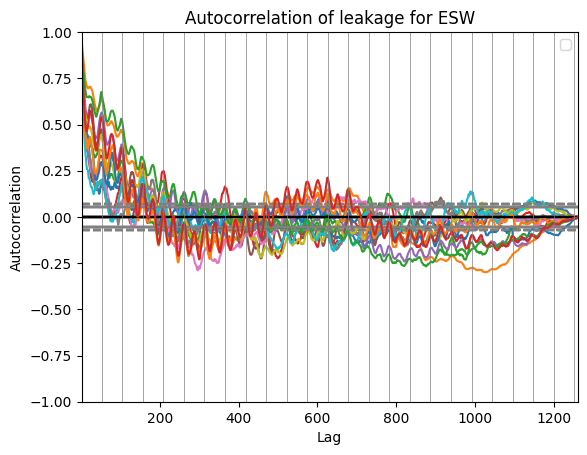

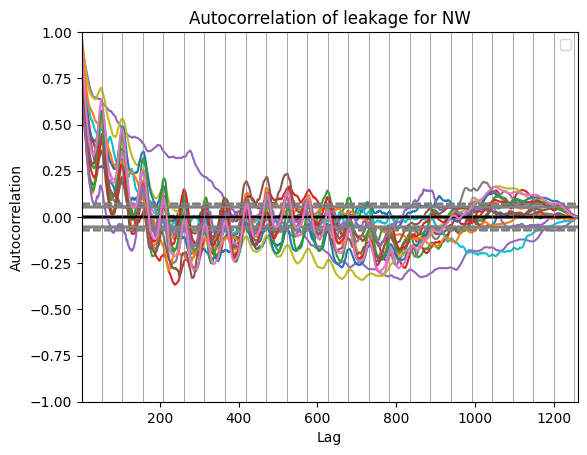

In [49]:
# Plot each zones autocorrelation
for name in ["ESW", "NW"]:
    for index, row in df[name].iterrows():
        pd.plotting.autocorrelation_plot(row)
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"Autocorrelation of leakage for {name}")
    period = 365.25 / 7
    # Plot vertical line after each period
    for i in range(1, int(len(row) / period) + 1):
        plt.axvline(
            x=i * period,
            color="grey",
            linestyle="-",
            lw=0.5,
        )
    plt.grid(False)
    plt.legend()
    plt.show()

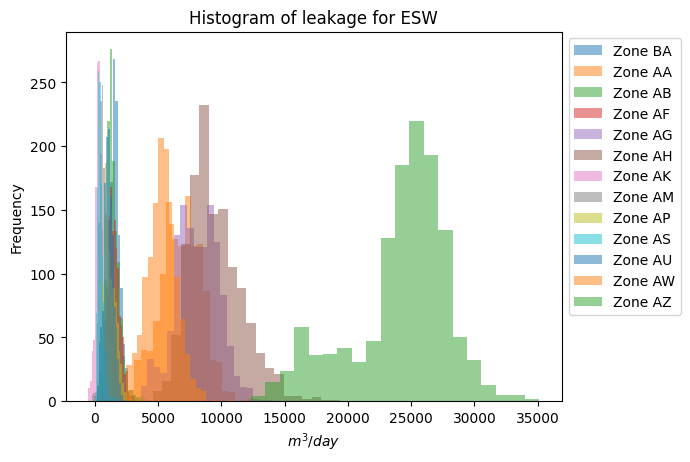

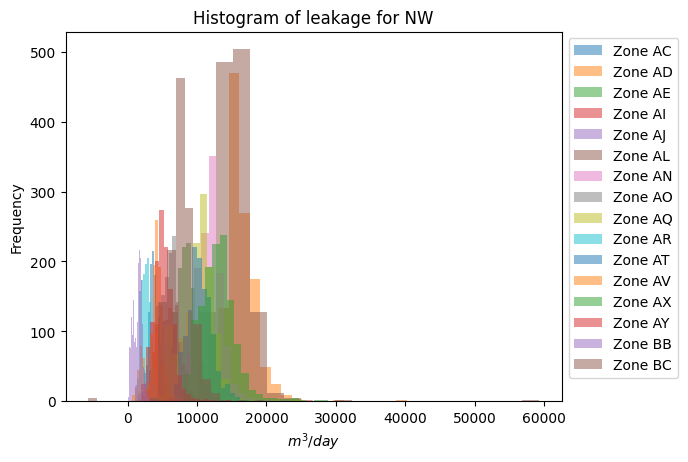

In [50]:
# Plot histograms of each zones leakage values
for name in ["ESW", "NW"]:
    for index, row in df[name].iterrows():
        if index == "Company":
            pass
        else:
            plt.hist(row.values, bins=20, alpha=0.5, label=index)
    plt.xlabel("$m^3/day$")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of leakage for {name}")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [51]:
# Define an ARIMA model
arimas = {}
for index, row in df["ESW"].iterrows():
    model = ARIMA(row, order=(1, 1, 1))
    model_fit = model.fit()
    arimas[index] = model_fit


/home/jens/Documents/Repos/VKEMS_Water/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/jens/Documents/Repos/VKEMS_Water/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/jens/Documents/Repos/VKEMS_Water/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/jens/Documents/Repos/VKEMS_Water/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/jens/Documents/Repos/VKEMS_Water/.

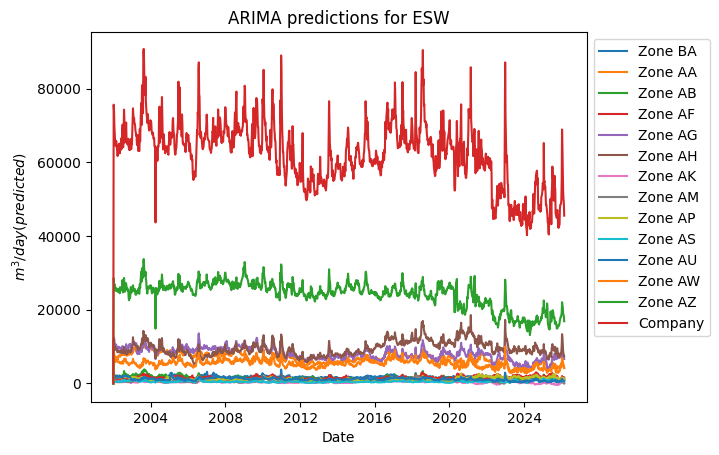

In [54]:
# Plot the ARIMA predictions for each row
for index, model_fit in arimas.items():
    predictions = model_fit.predict(start=0, end=len(df["ESW"].columns) - 1)
    plt.plot(df["ESW"].columns, predictions, label=index)
plt.xlabel("Date")
plt.ylabel("$m^3/day (predicted)$")
plt.title("ARIMA predictions for ESW")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_307093/3390018342.py:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta_{ARIMA}$")


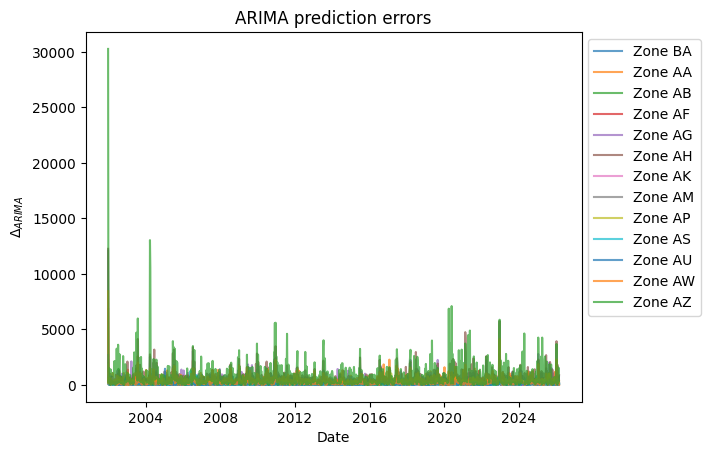

In [ ]:
# Plot the ARIMA predictions for each row
for index, model_fit in arimas.items():
    if index == "Company":
        pass
    else:
        rel_diffs = np.abs(model_fit.fittedvalues - df["ESW"].loc[index])
        plt.plot(rel_diffs, label=index, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("$\Delta_{ARIMA}$")
plt.title("ARIMA prediction errors")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

<>:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_307093/2482360707.py:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta_{leakage, ARIMA} / \sigma$")


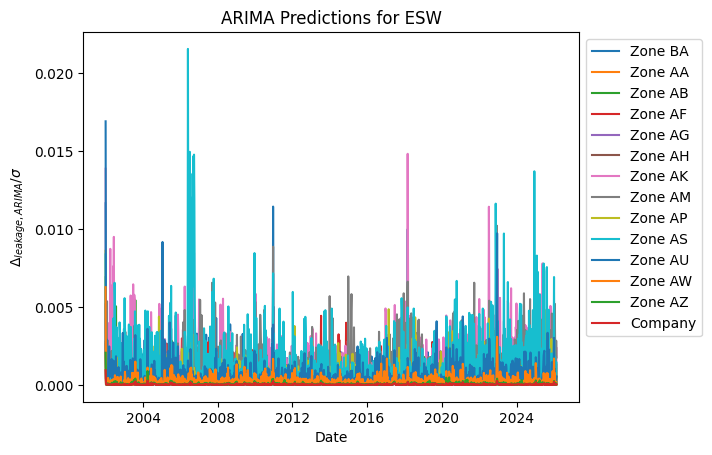

In [ ]:
# Plot the ARIMA predictions for each row
for index, model_fit in arimas.items():
    rel_diffs = (
        np.abs(model_fit.fittedvalues - df["ESW"].loc[index])
        / df["ESW"].loc[index].var()
    )
    plt.plot(rel_diffs, label=index)
plt.xlabel("Date")
plt.ylabel("$\Delta_{leakage, ARIMA} / \sigma$")
plt.title("ARIMA prediction errors normalized by leakage variance")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))